# *Real Estate Price Estimator*

## Exploratory Data Analysis

Before building the machine learning model, I explored the dataset to  understand the data better and identify the factors that influence house prices.

This involved examining the distribution of house prices, looking for relationships between different features and the sale price, checking for missing values, and identifying patterns that could help with feature selection. These insights provide a better understanding of the dataset before moving on to data preparation and model building.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("ggplot")

In [23]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv("AmesHousing.csv")
df.head()

Saving AmesHousing.csv to AmesHousing (1).csv


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [24]:
df.shape

(2930, 82)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [26]:
missing = df.isnull().sum()
missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Cond,159
Garage Yr Blt,159


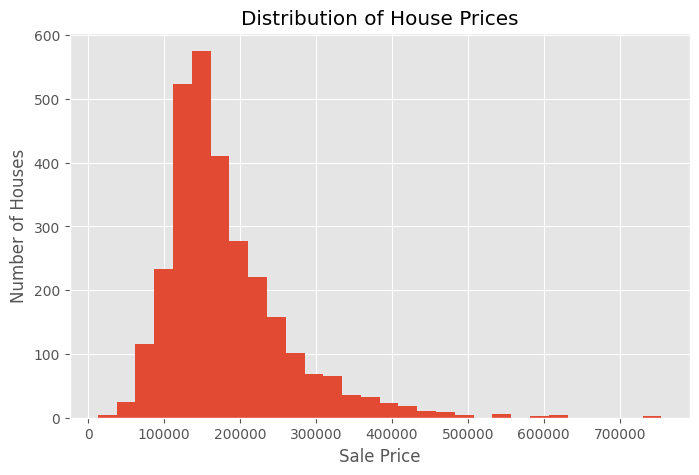

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df["SalePrice"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

Observation-Most houses are sold in the lower to middle price range, while only a small number of properties have very high sale prices. This creates a right-skewed distribution.

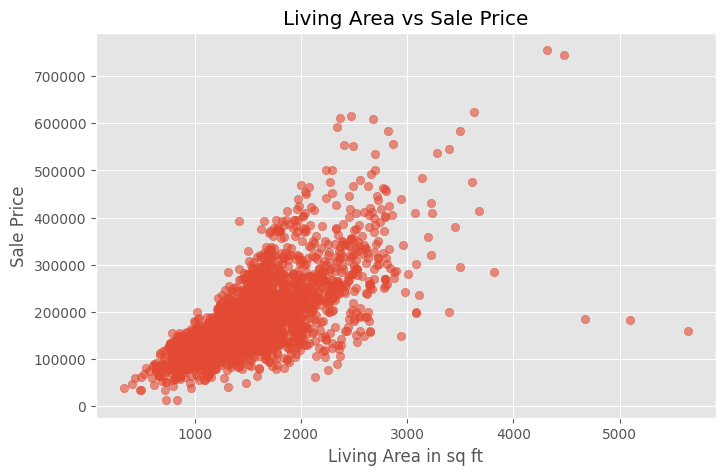

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.6)

plt.title("Living Area vs Sale Price")
plt.xlabel("Living Area in sq ft")
plt.ylabel("Sale Price")

plt.show()

Observation-Larger homes sell for higher prices. Although there are a few outliers, the overall trend suggests a positive relationship between living area and sale price.

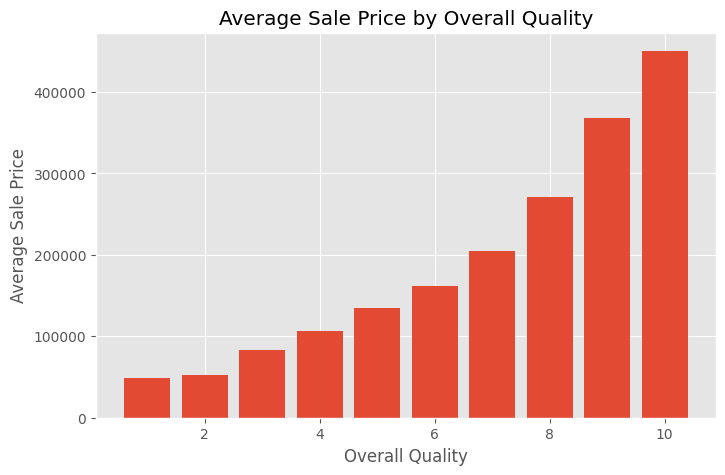

In [29]:
avg_price = df.groupby("Overall Qual")["SalePrice"].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_price.index, avg_price.values)

plt.title("Average Sale Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Average Sale Price")

plt.show()

Observation-Homes with higher overall quality ratings tend to have significantly higher average sale prices, making quality one of the strongest indicators of property value.

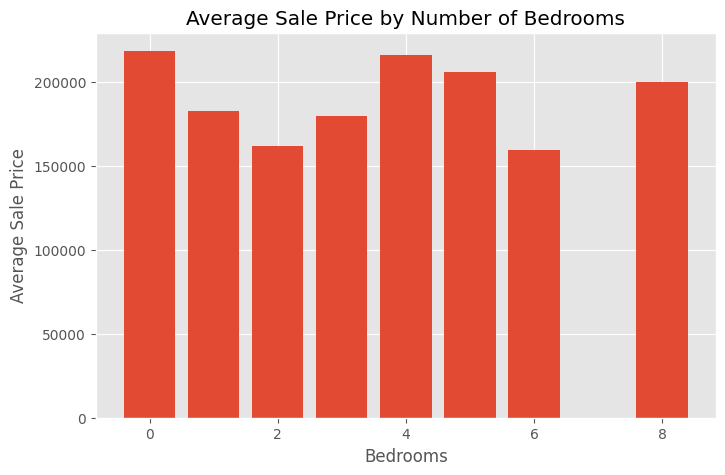

In [30]:
avg_price = df.groupby("Bedroom AbvGr")["SalePrice"].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_price.index, avg_price.values)

plt.title("Average Sale Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Sale Price")

plt.show()

Observation-Properties with more bedrooms have higher sale prices, although the increase is not perfectly consistent because other factors such as quality and living area also influence price.

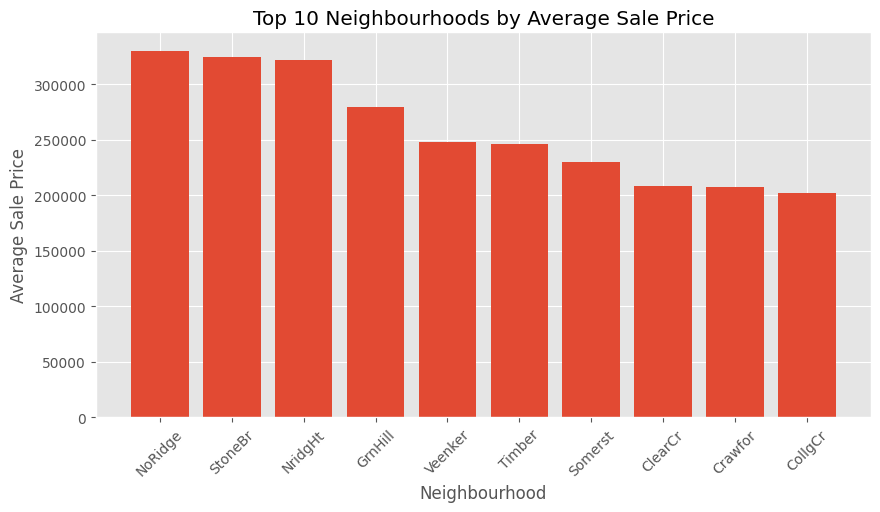

In [31]:
avg_price = df.groupby("Neighborhood")["SalePrice"].mean()

avg_price = avg_price.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(avg_price.index, avg_price.values)

plt.title("Top 10 Neighbourhoods by Average Sale Price")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Sale Price")
plt.xticks(rotation=45)

plt.show()

Observation-The most expensive neighbourhoods have significantly higher average sale prices, suggesting that location plays an important role in determining house value.

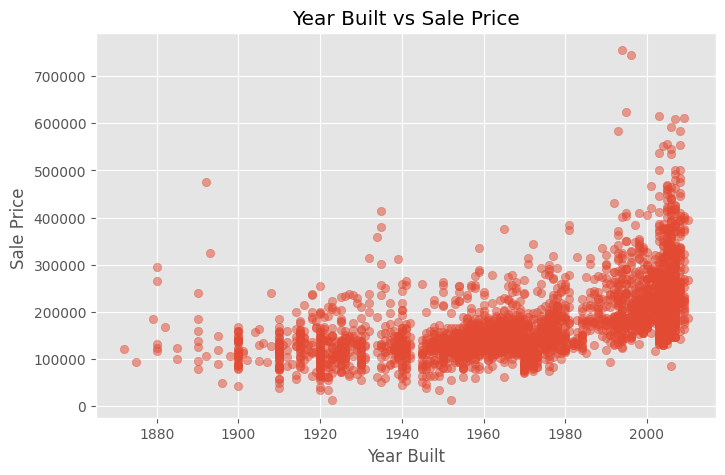

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(df["Year Built"], df["SalePrice"], alpha=0.5)

plt.title("Year Built vs Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price ")

plt.show()

 Observation-Newer homes generally tend to sell for higher prices, although there is still considerable variation due to other factors such as size, location and overall quality.

In [33]:
import seaborn as sns

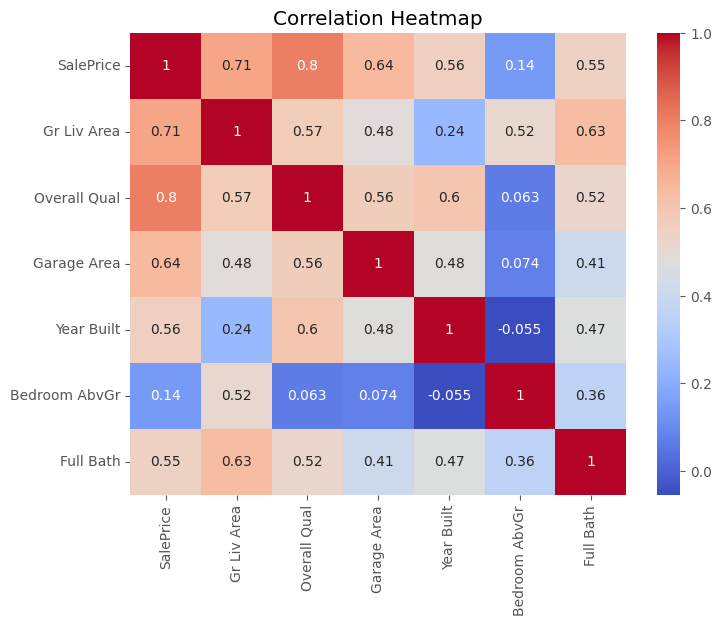

In [34]:
corr = df[["SalePrice",
           "Gr Liv Area",
           "Overall Qual",
           "Garage Area",
           "Year Built",
           "Bedroom AbvGr",
           "Full Bath"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

 Observation-Overall Quality and Living Area show the strongest positive correlation with Sale Price. Bedrooms have a weaker relationship, indicating that house size and quality are more important predictors than simply the number of bedrooms.

## EDA Summary

The exploratory analysis showed that house prices are affected by a combination of factors rather than a single feature. Living area, overall quality and neighbourhood all showed a clear relationship with sale price, while the correlation heatmap helped identify which variables were most strongly associated with the target variable.

The analysis also highlighted that the dataset contains missing values in several columns, which will need to be addressed before training the machine learning model. Overall, the EDA provided a solid understanding of the data and helped determine which features are likely to contribute most to accurate price predictions.

# Data Preparation

Before training the model, I selected the features that appeared to have the strongest relationship with house prices based on the exploratory analysis. I also checked for missing values and prepared the data for machine learning.

In [35]:
features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Area",
    "Full Bath",
    "Bedroom AbvGr",
    "Year Built"
]

X = df[features]

y = df["SalePrice"]

In [36]:
X.isnull().sum()

,0
Overall Qual,0
Gr Liv Area,0
Garage Area,1
Full Bath,0
Bedroom AbvGr,0
Year Built,0


In [37]:
X = X.fillna(X.median(numeric_only=True))

 Splitting the Data-

To evaluate the model fairly, I split the dataset into training and testing sets. The model learns from the training data and is then tested on data it has not seen before.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)

(2344, 6)
(586, 6)


 Training the Model

I used a Linear Regression model to predict house prices. Linear Regression works well when there is a linear relationship between the features and the target variable.

In [40]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [41]:
predictions = model.predict(X_test)

predictions[:10]

array([202207.74158693, 137033.89605323, 232743.6449061 ,  86526.35775916,
       114705.66664504, 174867.1849089 , 217710.58025806, 171454.9309649 ,
        66310.61344066, 294550.82473131])

In [44]:
mae = mean_absolute_error(y_test, predictions)

print("Mean absolute error:", mae)

Mean absolute error: 26881.279092948607


In [45]:
mse = mean_squared_error(y_test, predictions)

print("Mean squared error :", mse)

Mean squared error : 1728765605.2737725


In [46]:
rmse = np.sqrt(mse)

print("Root mean squared error:", rmse)

Root mean squared error: 41578.4271620966


In [50]:
r2 = r2_score(y_test, predictions)

print("R² score:", r2)

R² score: 0.7843772659456943


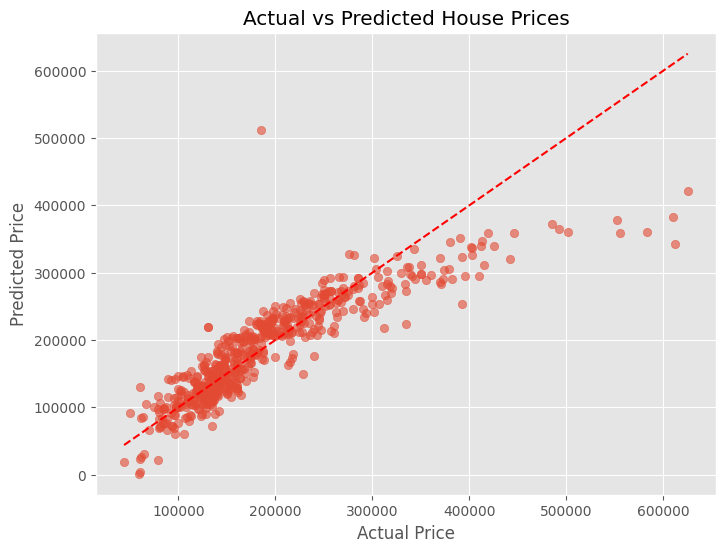

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

 Observation-Most predictions follow the general trend of the actual sale prices, although there is greater variation for more expensive properties. Overall, the model captures the relationship between the selected features and house prices reasonably well.

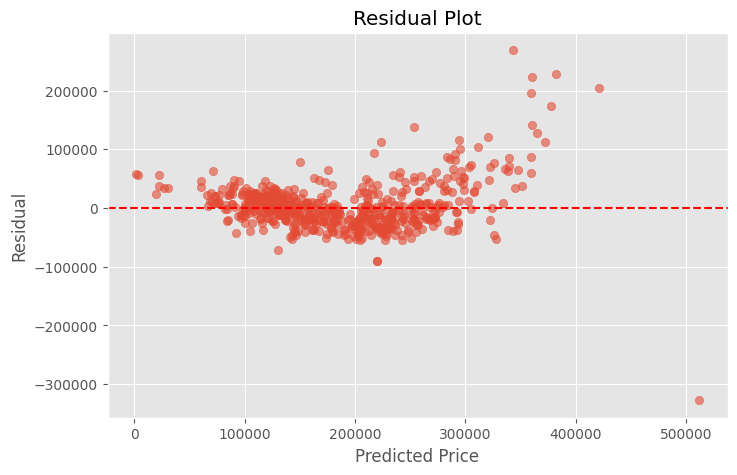

In [52]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter(predictions, residuals, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

Observation-The residuals are spread around zero without a strong pattern, suggesting that the model fits the data reasonably well. However, there are a few larger errors for higher-priced properties, indicating there is still room for improvement.

In [55]:
sample_house1 = pd.DataFrame({
    "Overall Qual": [8],
    "Gr Liv Area": [1800],
    "Garage Area": [500],
    "Full Bath": [2],
    "Bedroom AbvGr": [3],
    "Year Built": [2010]
})

predicted_price = model.predict(sample_house1)

print(f"Estimated House Price: {predicted_price[0]:,.2f}")

Estimated House Price: 256,771.59


In [54]:
sample_house2 = pd.DataFrame({
    "Overall Qual": [9],
    "Gr Liv Area": [2000],
    "Garage Area": [300],
    "Full Bath": [2],
    "Bedroom AbvGr": [2],
    "Year Built": [2013]
})

predicted_price = model.predict(sample_house2)

print(f"Estimated House Price: {predicted_price[0]:,.2f}")

Estimated House Price: 292,270.10


 Sample Prediction

To demonstrate the model, I tested it using the features of a hypothetical property. The model returned an estimated sale price based on the patterns it learned from the training data.

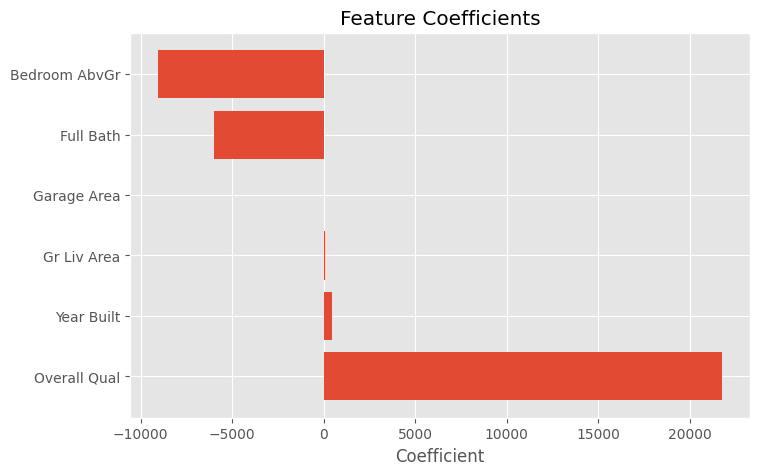

In [57]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
importance = importance.sort_values("Coefficient", ascending=False)
plt.figure(figsize=(8,5))

plt.barh(importance["Feature"], importance["Coefficient"])

plt.title("Feature Coefficients")

plt.xlabel("Coefficient")

plt.show()

Observation

The coefficients show how each feature influences the predicted sale price. Positive coefficients indicate that an increase in that feature is associated with a higher predicted price, while negative coefficients suggest the opposite.

# Conclusion

In this project, I built a Linear Regression model to predict residential property prices using the Ames Housing dataset.

I started by exploring the dataset to understand the relationships between different housing features and sale prices. After selecting the most relevant features and handling missing values, I trained and evaluated a machine learning model using a train-test split.

The evaluation showed that the model was able to capture the general relationship between the selected features and house prices, although prediction errors were larger for some higher-value properties.

This project helped me gain practical experience with the complete machine learning workflow, including data exploration, preprocessing, model training, evaluation and prediction.